In [1]:
#Previsão do preço das prinipais açõs petroleiras da B3, utilizando LSTM e análise de sentimento


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM


In [3]:
#Cotação das principais ações de petróleo da B3 (utilizando o Yahoo Fynance) dos últimos 4 meses, pegando somente o fechamento
df_cotacoes = pd.DataFrame(yf.download(['PETR4.SA', 'PRIO3.SA', 'BRAV3.SA', 'RECV3.SA', 'UGPA3.SA', 'CSAN3.SA'],period='5y'))['Close']

[*********************100%***********************]  6 of 6 completed


In [4]:
df_cotacoes

Ticker,BRAV3.SA,CSAN3.SA,PETR4.SA,PRIO3.SA,RECV3.SA,UGPA3.SA
Date,,,,,,
2021-06-01,39.594513,21.729946,7.991519,19.628473,10.563888,7.859567
2021-06-02,39.796375,21.919764,8.161365,20.247480,10.557403,7.920316
2021-06-04,39.642574,22.236134,8.345852,20.467127,10.888134,8.026629
2021-06-07,38.517895,22.516342,8.284355,19.668409,10.648192,8.098771
2021-06-08,38.460217,22.543461,8.392704,19.289019,10.479584,8.034223
...,...,...,...,...,...,...
2026-05-26,20.070000,4.280000,43.439999,64.750000,11.900000,27.870001
2026-05-27,19.910000,4.010000,42.820000,62.980000,11.810000,27.480000
2026-05-28,20.240000,3.940000,42.509998,62.970001,11.580000,26.910000


In [5]:
#Convertendo para para o formato datetime, será util para a manipulação dos dados
df_cotacoes.index = pd.to_datetime(df_cotacoes.index)

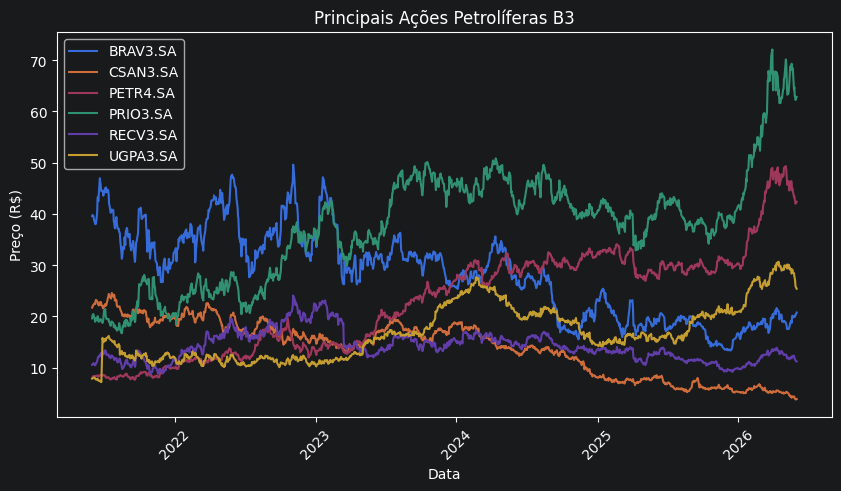

In [6]:
#Visualizando os dados:
plt.figure(figsize=(10,5))
plt.title('Principais Ações Petrolíferas B3')
plt.ylabel('Preço (R$)')
plt.xlabel('Data')
plt.xticks(rotation=45)
plt.plot(df_cotacoes)
plt.legend(df_cotacoes.columns)
plt.show()

In [7]:
#Separando os dados em treino e teste, utilizando a métrica 80/20
tamanho_treino = int(len(df_cotacoes)*0.8)
dados_treino = df_cotacoes.iloc[:tamanho_treino]
dados_teste = df_cotacoes.iloc[tamanho_treino:]
print(len(dados_treino), len(dados_teste))

997 250


In [8]:
#Normalizando os dados utilizando o min max scaller para o intervalo (0,1)
#MinMax scaller vai escalar cada coluna individualmente (pois são 6 ações diferentes)
scaler = MinMaxScaler(feature_range=(0, 1))

#É interessante escalar apenas os dados de treino, para evitar data leakage (vazamento de dados)
treino_escalado = scaler.fit_transform(dados_treino)
teste_escalado = scaler.transform(dados_teste)

In [9]:
#Criando a função que trabalha com a janela temporal dos dados
def criar_sequencias(dados, janela=60):
    x, y = [], []
    for i in range(janela, len(dados)):
        x.append(dados[i-janela:i]) #Historico da janela tempral, no caso os ultimos 60 dias
        y.append(dados[i]) #Preço alvo do dia atual (para as 6 ações)
    return np.array(x), np.array(y)

In [10]:
#Definindo a janela temporal e criando os dados de treino
janela_temporal = 60 #padrão para analise de ações (2meses)

x_treino, y_treino = criar_sequencias(treino_escalado, janela_temporal)

In [11]:
#Criando e ajustando os dados de teste
#É necessário a concatenação dos ultimos dias de treino para não perder o inicio do teste
total_dados_teste = pd.concat((dados_treino.tail(janela_temporal), dados_teste), axis=0)
total_dados_escalado = scaler.transform(total_dados_teste)

#Criando os dados de teste
x_teste, y_teste = criar_sequencias(total_dados_escalado, janela_temporal)

In [12]:
print(f"Formato Treino: {x_treino.shape}, {y_treino.shape}")
print(f"Formato Teste: {x_teste.shape}, {y_teste.shape}")

Formato Treino: (937, 60, 6), (937, 6)
Formato Teste: (250, 60, 6), (250, 6)


In [13]:
#Construindo o modelo

#Dimensões:
passos = x_treino.shape[1] #60 dias
recursos = x_treino.shape[2] #as 6 ações

modelo = Sequential(
    [LSTM(units=50, return_sequences=True, input_shape=(passos, recursos)),
     Dropout(0.2),
     LSTM(units=50, return_sequences=False),
     Dropout(0.2),
     Dense(units=recursos), #Por se tratar de 6 ações diferentes a camada Dense tem que ter exatamente 6 neuronios de saída
    ])


C:\Users\Rafael\PyCharmMiscProject\.venv313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
#Compilando o modelo
modelo.compile(optimizer='adam', loss='mse')
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,906 (124.63 KB)

 Trainable params: 31,906 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#Treinando o modelo
historico = modelo.fit(x_treino, y_treino, epochs=25, batch_size=32, validation_data=(x_teste, y_teste))

Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0827 - val_loss: 0.0303
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0208 - val_loss: 0.0293
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0165 - val_loss: 0.0271
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0147 - val_loss: 0.0213
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0126 - val_loss: 0.0248
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0119 - val_loss: 0.0206
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0113 - val_loss: 0.0231
Epoch 8/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0108 - val_loss: 0.0179
Epoch 9/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0101 - val_loss: 0.0184
Epoch 10/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0095 - val_loss: 0.0183
Epoch 11/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0095 - val_loss: 0.0144
Epoch 12/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0

In [17]:
#Realizar as previsões, e reverter a normalização para exibir os valores em R$
predicoes_escaladas = modelo.predict(x_teste)

#Invertendo a normalização
predicoes = scaler.inverse_transform(predicoes_escaladas)
valores_reais = scaler.inverse_transform(y_teste)
index_alinhado = dados_teste.index[janela_temporal:] #ajustar o indice temporal para pular os primeiros dias da janela temporal



8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
